In [ ]:
import pandas as pd

rainfall = pd.read_csv("rainfall.csv")
temp = pd.read_csv("temp.csv")
pesticides = pd.read_csv("pesticides.csv")
yield_df = pd.read_csv("yield.csv")

print("Rainfall shape:", rainfall.shape)
print("Temp shape:", temp.shape)
print("Pesticides shape:", pesticides.shape)
print("Yield shape:", yield_df.shape)

Rainfall shape: (6727, 3)
Temp shape: (71311, 3)
Pesticides shape: (4349, 7)
Yield shape: (56717, 12)


In [ ]:
print("\nRainfall Columns:")
print(rainfall.columns)

print("\nTemp Columns:")
print(temp.columns)

print("\nPesticides Columns:")
print(pesticides.columns)

print("\nYield Columns:")
print(yield_df.columns)


Rainfall Columns:
Index([' Area', 'Year', 'average_rain_fall_mm_per_year'], dtype='object')

Temp Columns:
Index(['year', 'country', 'avg_temp'], dtype='object')

Pesticides Columns:
Index(['Domain', 'Area', 'Element', 'Item', 'Year', 'Unit', 'Value'], dtype='object')

Yield Columns:
Index(['Domain Code', 'Domain', 'Area Code', 'Area', 'Element Code', 'Element',
       'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value'],
      dtype='object')


In [ ]:
# Remove spaces from column names
rainfall.columns = rainfall.columns.str.strip()
temp.columns = temp.columns.str.strip()
pesticides.columns = pesticides.columns.str.strip()
yield_df.columns = yield_df.columns.str.strip()

# Rename columns to make them consistent

# Rainfall (already correct after strip)

# Temp
temp.rename(columns={
    'country': 'Area',
    'year': 'Year'
}, inplace=True)

# Pesticides → keep only useful columns
pesticides = pesticides[['Area', 'Year', 'Value']]
pesticides.rename(columns={'Value': 'pesticides'}, inplace=True)

# Yield → keep only useful columns
yield_df = yield_df[['Area', 'Item', 'Year', 'Value']]
yield_df.rename(columns={'Value': 'yield'}, inplace=True)

In [ ]:
import numpy as np

# Replace invalid values
rainfall['average_rain_fall_mm_per_year'] = rainfall['average_rain_fall_mm_per_year'].replace('..', np.nan)

# Convert to numeric
rainfall['average_rain_fall_mm_per_year'] = pd.to_numeric(
    rainfall['average_rain_fall_mm_per_year'],
    errors='coerce'
)

# Drop missing values
rainfall = rainfall.dropna(subset=['average_rain_fall_mm_per_year'])

              Year  average_rain_fall_mm_per_year
count  5947.000000                    5947.000000
mean   2001.365899                    1124.743232
std       9.526335                     786.257365
min    1985.000000                      51.000000
25%    1993.000000                     534.000000
50%    2001.000000                    1010.000000
75%    2010.000000                    1651.000000
max    2017.000000                    3240.000000


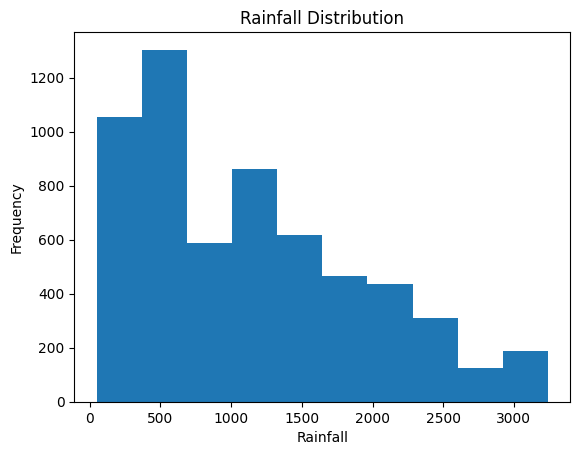

In [ ]:
print(rainfall.describe())

plt.figure()
plt.hist(rainfall['average_rain_fall_mm_per_year'])
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")
plt.show()

               Year      avg_temp
count  71311.000000  68764.000000
mean    1905.799007     16.183876
std       67.102099      7.592960
min     1743.000000    -14.350000
25%     1858.000000      9.750000
50%     1910.000000     16.140000
75%     1962.000000     23.762500
max     2013.000000     30.730000


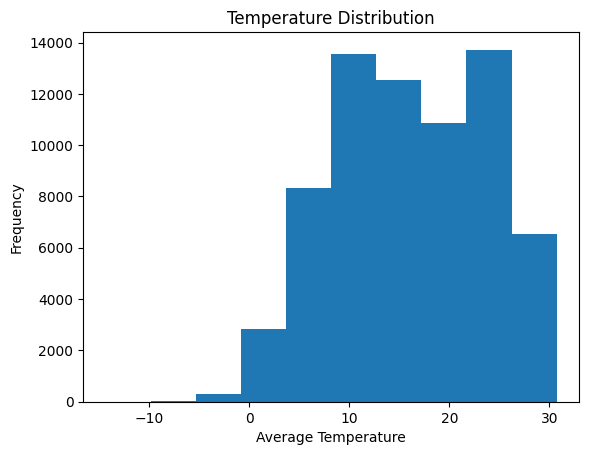

In [ ]:
# Check basic stats
print(temp.describe())

# Histogram
plt.figure()
plt.hist(temp['avg_temp'])
plt.title("Temperature Distribution")
plt.xlabel("Average Temperature")
plt.ylabel("Frequency")
plt.show()

In [ ]:
temp = temp[(temp['Year'] >= 1985) & (temp['Year'] <= 2017)]

In [ ]:
print(temp['Year'].min(), temp['Year'].max())
print(temp.shape)

1985 2013
(10005, 3)


              Year    pesticides
count  4349.000000  4.349000e+03
mean   2003.138883  2.030334e+04
std       7.728044  1.177362e+05
min    1990.000000  0.000000e+00
25%    1996.000000  9.300000e+01
50%    2003.000000  1.137560e+03
75%    2010.000000  7.869000e+03
max    2016.000000  1.807000e+06


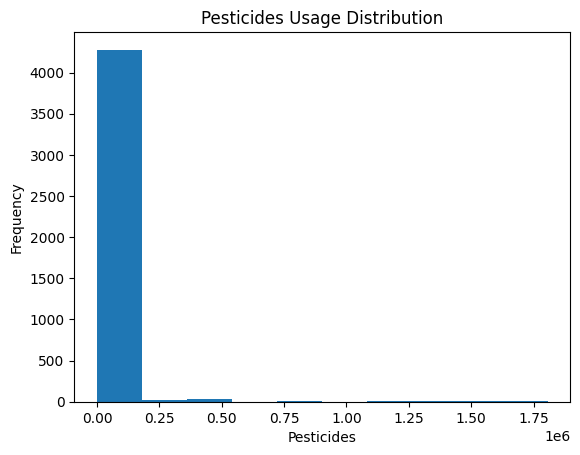

In [ ]:
# Convert to numeric if needed
pesticides['pesticides'] = pd.to_numeric(pesticides['pesticides'], errors='coerce')

# Drop missing
pesticides = pesticides.dropna(subset=['pesticides'])

# Basic stats
print(pesticides.describe())

# Histogram
import matplotlib.pyplot as plt

plt.figure()
plt.hist(pesticides['pesticides'])
plt.title("Pesticides Usage Distribution")
plt.xlabel("Pesticides")
plt.ylabel("Frequency")
plt.show()

               Year           yield
count  56717.000000    56717.000000
mean    1989.669570    62094.660084
std       16.133198    67835.932856
min     1961.000000        0.000000
25%     1976.000000    15680.000000
50%     1991.000000    36744.000000
75%     2004.000000    86213.000000
max     2016.000000  1000000.000000


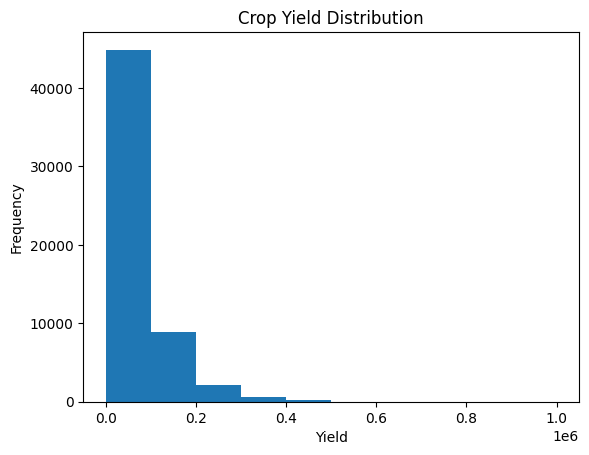

In [ ]:
# Convert yield to numeric if needed
yield_df['yield'] = pd.to_numeric(yield_df['yield'], errors='coerce')

# Drop missing
yield_df = yield_df.dropna(subset=['yield'])

# Stats
print(yield_df.describe())

# Histogram
plt.figure()
plt.hist(yield_df['yield'])
plt.title("Crop Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Merge datasets step-by-step
df = yield_df.merge(rainfall, on=['Area', 'Year'])
df = df.merge(temp, on=['Area', 'Year'])
df = df.merge(pesticides, on=['Area', 'Year'])

# Check result
print(df.shape)
print(df.head())
print(df.isnull().sum())

(28242, 7)
      Area   Item  Year  yield  average_rain_fall_mm_per_year  avg_temp  \
0  Albania  Maize  1990  36613                         1485.0     16.37   
1  Albania  Maize  1991  29068                         1485.0     15.36   
2  Albania  Maize  1992  24876                         1485.0     16.06   
3  Albania  Maize  1993  24185                         1485.0     16.05   
4  Albania  Maize  1994  25848                         1485.0     16.96   

   pesticides  
0       121.0  
1       121.0  
2       121.0  
3       121.0  
4       201.0  
Area                             0
Item                             0
Year                             0
yield                            0
average_rain_fall_mm_per_year    0
avg_temp                         0
pesticides                       0
dtype: int64


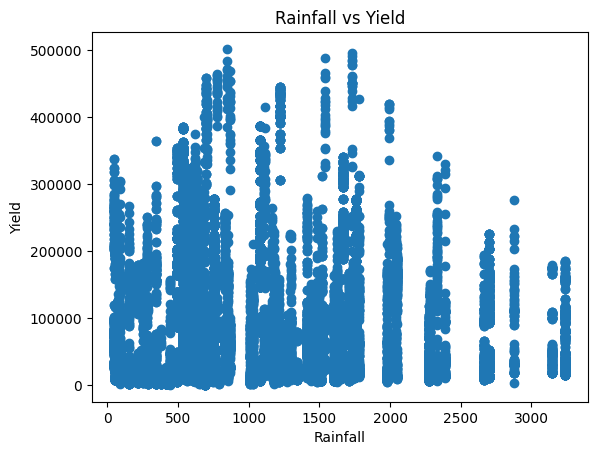

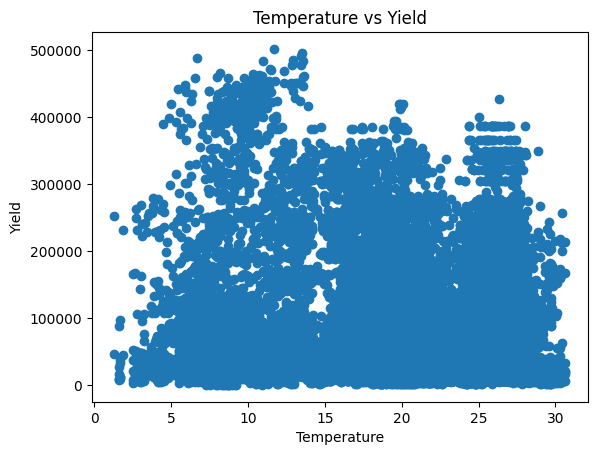

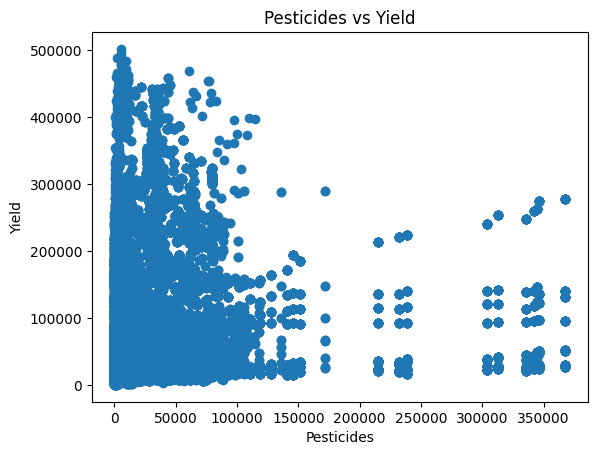

In [ ]:
import matplotlib.pyplot as plt

# Rainfall vs Yield
plt.figure()
plt.scatter(df['average_rain_fall_mm_per_year'], df['yield'])
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.show()

# Temperature vs Yield
plt.figure()
plt.scatter(df['avg_temp'], df['yield'])
plt.title("Temperature vs Yield")
plt.xlabel("Temperature")
plt.ylabel("Yield")
plt.show()

# Pesticides vs Yield
plt.figure()
plt.scatter(df['pesticides'], df['yield'])
plt.title("Pesticides vs Yield")
plt.xlabel("Pesticides")
plt.ylabel("Yield")
plt.show()

In [ ]:
# Convert crop type into numerical form
df = pd.get_dummies(df, columns=['Item'])

# Define features and target
X = df.drop(['yield', 'Area'], axis=1)
y = df['yield']

print(X.shape)

(28242, 14)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(22593, 14) (5649, 14)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression Predictions
pred_lr = lr.predict(X_test)

# Random Forest Predictions
pred_rf = rf.predict(X_test)

# Evaluation

print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R2:", r2_score(y_test, pred_lr))

print("\nRandom Forest:")
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R2:", r2_score(y_test, pred_rf))

Linear Regression:
MAE: 31711.970415638283
RMSE: 50579.57618332562
R2: 0.6427271829689012

Random Forest:
MAE: 3953.653581164808
RMSE: 10409.490796372336
R2: 0.984867573490439


In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                          Feature  Importance
7                   Item_Potatoes    0.375655
2                        avg_temp    0.122324
3                      pesticides    0.117167
1   average_rain_fall_mm_per_year    0.116500
4                    Item_Cassava    0.096513
11            Item_Sweet potatoes    0.087721
0                            Year    0.030469
13                      Item_Yams    0.027367
6       Item_Plantains and others    0.015351
8                Item_Rice, paddy    0.004134
5                      Item_Maize    0.003362
10                  Item_Soybeans    0.002238
12                     Item_Wheat    0.000847
9                    Item_Sorghum    0.000353
